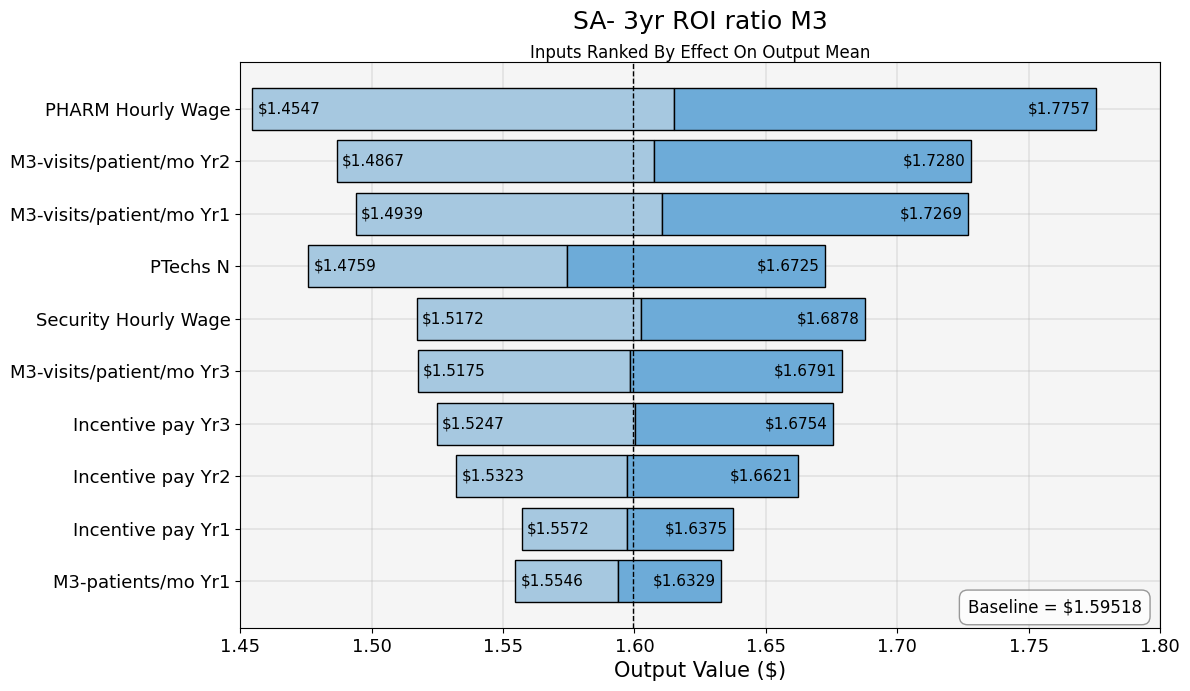

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

# Reading new CSV
df = pd.read_csv(r"C:\Users\murra\Downloads\M3SA-_ROIRatio_Tornado_2025-07-19(Sheet1).csv")

# Cleaning and computing
df.rename(columns={'Unnamed: 0': 'Parameter'}, inplace=True)
df['Y'] = pd.to_numeric(df['Y'], errors='coerce')
df['Y2'] = pd.to_numeric(df['Y2'], errors='coerce')

df['Mid'] = (df['Y'] + df['Y2']) / 2
df['Diff'] = abs(df['Y2'] - df['Y'])
df = df.sort_values('Diff', ascending=True)

# Plotting settings
mpl.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 18,
    'axes.labelsize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13,
    'axes.facecolor': '#f5f5f5'
})

fig, ax = plt.subplots(figsize=(12, 7))

problematic_labels = [
]

# Label offsets and threshold
inside_pad = 5
outside_pad = 10
width_threshold = 0.15 

# Plot bars
for _, row in df.iterrows():
    y_pos = str(row['Parameter'])
    y1 = row['Y']
    y2 = row['Y2']
    label_L = f"${float(row['L']):,.4f}"
    label_L2 = f"${float(row['L2']):,.4f}"

    start = min(y1, y2)
    end = max(y1, y2)
    mid = (y1 + y2) / 2

    # Left bar
    ax.barh(y_pos, mid - start, left=start, color="#a6c8e0", edgecolor='black')
    # Right bar
    ax.barh(y_pos, end - mid, left=mid, color="#6dabd8", edgecolor='black')

    ax.text(start + 0.002, y_pos, label_L, va='center', ha='left', fontsize=11)
    ax.text(end - 0.002, y_pos, label_L2, va='center', ha='right', fontsize=11)

# Reference line
baseline = df['Mid'].mean()
ax.axvline(x=baseline, color='black', linestyle='--', linewidth=1)

# Axis and titles
ax.set_xlim(1.45, 1.80)
ax.set_xlabel('Output Value ($)')
ax.set_title("")
ax.text(0.5, 1.05, "SA- 3yr ROI ratio M3", fontsize=18,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(0.5, 1.00, "Inputs Ranked By Effect On Output Mean", fontsize=12,
        ha='center', va='bottom', transform=ax.transAxes)
ax.text(
    0.98, 0.02,
    f'Baseline = $1.59518',
    fontsize=12,
    ha='right', va='bottom',
    transform=ax.transAxes,
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="gray", alpha=0.8)
)

# Grid and layout
ax.grid(True, linewidth=0.35, alpha=1)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()